# Data assimilation and flow inversion

Given a snapshot of a fluid flow now, what did it look like earlier? Where was a contaminant released? How do
you turn sparse, noisy measurements into the best estimate of a whole flow field -- and a forecast? These are
the questions of data assimilation, the discipline that initialises every weather forecast and reconstructs
oceans, atmospheres, and plumes from incomplete data. This notebook is a self-contained course in it, from no
background to fluency, built on the incompressible Navier-Stokes equations:

1. The data-assimilation problem and where it is used.
2. The forward model -- incompressible Navier-Stokes, vorticity, and mixing.
3. The inverse problem and irreversibility -- why running a viscous flow backward is hard.
4. The methods -- 4D-Var, the Kalman filter and ensemble filters, and the Bayesian view.
5. Bayesian initial-state inversion on mixle, with uncertainty.
6. Scale-dependent recovery -- diffusion erases the small scales first.
7. The reversibility horizon -- how far back the flow can be read.
8. Sparse observation and observability.
9. Inferring a parameter (the viscosity) instead of the state.
10. Best practices and the links to operational forecasting.

The inversions are `mixle`: a `GP` field for the unknown, a `NavierStokes2D` forward run through time,
and `joint().fit(how='gauss_newton')` differentiating through the time loop -- returning a posterior over the
past state, with an uncertainty that grows exactly as the flow forgets its history.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, torch
import matplotlib.pyplot as plt
from mixle.ppl import GP, RBF, joint
from mixle_pde import Differential, NavierStokes2D
from mixle_pde.ops import make_ops
ops = make_ops()
m = 22; h = 1.0 / (m - 1); dt = 0.08 * h
gx = np.linspace(0, 1, m); xx, yy = np.meshgrid(gx, gx, indexing='ij')
w0_true = (3.0 * np.exp(-((xx - 0.40) ** 2 + (yy - 0.55) ** 2) / 0.006)
           - 2.5 * np.exp(-((xx - 0.60) ** 2 + (yy - 0.45) ** 2) / 0.020)).ravel()
def evolve(ns, w0, nt, snapshots=()):
    w = torch.as_tensor(w0) * torch.as_tensor(ns._mask); snaps = {}
    for i in range(nt + 1):
        if i in snapshots: snaps[i] = w.detach().numpy().copy()
        if i < nt: w = ns.step(w, ops)
    return w, snaps
ns = NavierStokes2D(m, viscosity=0.01, dt=dt, implicit_diffusion=True); nt = 40
print('%dx%d grid, %d time steps, viscosity 0.01 -- two vortices of different size advect and diffuse' % (m, m, nt))

22x22 grid, 40 time steps, viscosity 0.01 -- two vortices of different size advect and diffuse


## 1. The data-assimilation problem

Data assimilation combines a dynamical model with observations to estimate the state of a system -- and it is
everywhere a model meets data over time. Numerical weather prediction is the giant: every forecast starts by
assimilating millions of sparse, noisy observations (stations, satellites, balloons) into the best estimate
of the current atmosphere, because a forecast is only as good as its initial condition. The same machinery
reconstructs ocean currents, tracks pollutant and wildfire-smoke plumes back to their source, initialises
reservoir and epidemic models, and fuses sensors in navigation. Two flavours recur: state estimation (recover
the field now or earlier) and parameter estimation (recover a coefficient like viscosity or a diffusivity).
What unites them is an inverse problem with a PDE in the loop -- infer the inputs of a simulation from partial,
indirect observations of its output -- which is exactly what we set up next.

## 2. The forward model: incompressible Navier-Stokes

The flow obeys the incompressible Navier-Stokes equations, which we write in vorticity-streamfunction form:
the vorticity $\omega = \nabla\times\mathbf u$ is advected by the flow and diffused by viscosity,
$$ \partial_t \omega + \mathbf u\cdot\nabla\omega = \nu\,\nabla^2\omega, \qquad \nabla^2\psi = -\omega,\quad
\mathbf u = \nabla^\perp\psi, $$
with the velocity recovered from the streamfunction $\psi$. The ratio of advection to diffusion is the
Reynolds number; viscosity $\nu$ sets how fast small-scale structure is smeared out. `NavierStokes2D`
integrates this (streamfunction-vorticity, with an implicit diffusion step for stability at higher
viscosity). Starting from two vortices of different size, watch the field advect and diffuse -- the fine
vortex blurs faster than the coarse one, a fact that will dominate the inverse problem.

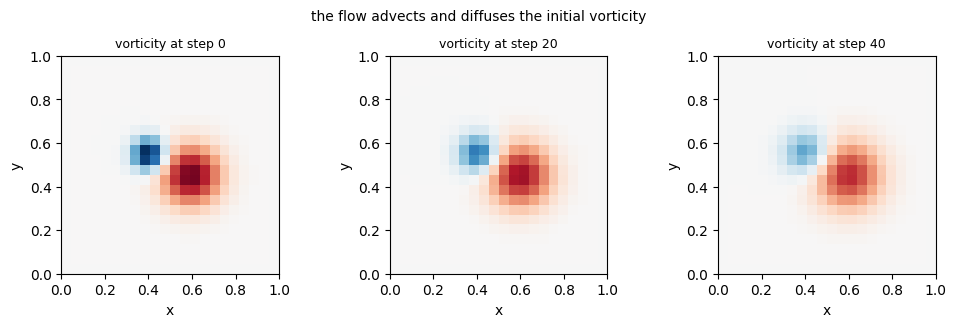

In [2]:
_, snaps = evolve(ns, w0_true, nt, snapshots=(0, nt // 2, nt))
v = np.abs(w0_true).max()
fig, ax = plt.subplots(1, 3, figsize=(10, 3.2))
for a, i in zip(ax, (0, nt // 2, nt)):
    a.imshow(snaps[i].reshape(m, m).T, origin='lower', extent=[0, 1, 0, 1], cmap='RdBu', vmin=-v, vmax=v)
    a.set_title('vorticity at step %d' % i, fontsize=9); a.set_xlabel('x'); a.set_ylabel('y')
fig.suptitle('the flow advects and diffuses the initial vorticity', fontsize=10); plt.tight_layout(); plt.show()

## 3. The inverse problem and irreversibility

Now reverse the arrow: observe the flow later and infer its earlier state. This is harder than the forward
run for a deep reason -- irreversibility. Advection alone is reversible (run the velocities backward and the
fluid retraces its path), but diffusion is not: it smooths gradients and destroys information, exactly like
heat spreading or cream mixing into coffee. Running diffusion backward amplifies noise catastrophically. So
the recoverable past is limited, and a good method must report not just an estimate but how much of the past
can still be known -- the uncertainty must grow with how long the flow has been mixing. The variational view
makes this concrete: we seek the initial state whose forward evolution best matches the observations,
regularised by a prior, which is precisely the Bayesian inverse we now build.

## 4. The methods: 4D-Var, Kalman, ensembles, and the Bayesian view

Operational data assimilation has two great families. Variational methods (3D-Var, 4D-Var) minimise a cost
function -- the mismatch between a model trajectory and all the observations over a window, plus a background
(prior) term -- by adjoint-gradient descent; 4D-Var is the workhorse of major weather centres and is exactly a
MAP estimate of the initial state. Sequential methods (the Kalman filter and, for nonlinear high-dimensional
systems, the ensemble Kalman filter) propagate a state estimate and its covariance forward, updating as
observations arrive, and naturally produce uncertainty. Both are special cases of Bayesian inference: a prior
on the unknown, a likelihood from the observations through the model, a posterior over the state. The
Gauss-Newton inversion we use is a Bayesian 4D-Var with the bonus of a posterior covariance: the gradient is
taken through the whole time loop by automatic differentiation (the adjoint), and the low-rank posterior
gives per-cell uncertainty.

## 5. Bayesian initial-state inversion

We observe the velocity field at the final step (with noise) and recover the initial vorticity. The initial
field is a latent `GP`; the forward model integrates Navier-Stokes to the observation time and reads the
velocity; `joint([...]).fit(how='gauss_newton')` differentiates through the time loop and returns the
posterior. The recovered initial field and its uncertainty follow.

initial-state recovery: correlation with truth = 0.886


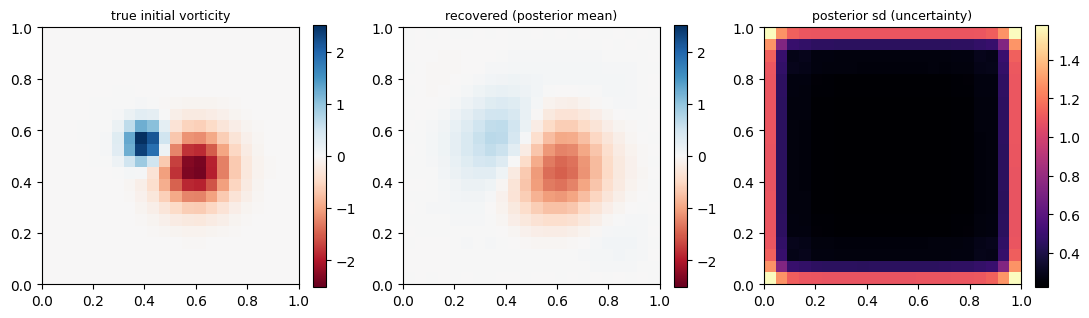

In [3]:
def final_velocity(ns, w0, nt):
    w, _ = evolve(ns, w0, nt); u, v_ = ns.velocity(ns.streamfunction(w, ops), ops)
    sens = torch.as_tensor(np.where(ns._mask > 0)[0]); return torch.cat([u[sens], v_[sens]])
y_clean = final_velocity(ns, torch.as_tensor(w0_true), nt).detach().numpy()
rng = np.random.RandomState(0); sig = 0.04 * np.abs(y_clean).max(); y_obs = y_clean + sig * rng.randn(y_clean.size)
field = GP('w0', index=np.stack([xx.ravel(), yy.ravel()], 1), kernel=RBF(lengthscale=0.09, amplitude=2.0))
post = joint([Differential(y_obs, over=field, scale=sig, forward=lambda p, o: final_velocity(ns, p.field, nt))]).fit(
    # 0.8.0 refuses to return an unconverged MAP. tolerance_grad is an ABSOLUTE bound on the
    # gradient's max-norm, but this objective is scaled by 1/sigma^2 (~5e4 here), so the 1e-6
    # default is unreachable by construction. Converge to 1e-3 in the data's own noise units.
    how='gauss_newton', max_iter=300, tolerance_grad=1e-3 / sig ** 2)
w0_mean, w0_sd = post.posterior('w0')
print('initial-state recovery: correlation with truth = %.3f' % np.corrcoef(w0_mean, w0_true)[0, 1])
img = lambda f: f.reshape(m, m).T; v = np.abs(w0_true).max()
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
for a, (t, F, cm, kw) in zip(ax, [('true initial vorticity', w0_true, 'RdBu', dict(vmin=-v, vmax=v)),
                                  ('recovered (posterior mean)', w0_mean, 'RdBu', dict(vmin=-v, vmax=v)),
                                  ('posterior sd (uncertainty)', w0_sd, 'magma', {})]):
    im = a.imshow(img(F), origin='lower', extent=[0, 1, 0, 1], cmap=cm, **kw); a.set_title(t, fontsize=9); fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

## 6. Scale-dependent recovery

The recovery is not uniform across scales. Diffusion erases small-scale structure fastest (its rate grows
with the square of the wavenumber), so by the observation time the fine vortex has been smeared far more than
the coarse one, and less of it survives in the data to be recovered. The reconstruction shows it: the coarse
vortex comes back sharply, the fine one weakly and with higher uncertainty. This is the spatial signature of
irreversibility -- the flow forgets its high-frequency detail first.

In [4]:
fine_mask = np.exp(-((xx - 0.40) ** 2 + (yy - 0.55) ** 2) / 0.006).ravel() > 0.3
coarse_mask = np.exp(-((xx - 0.60) ** 2 + (yy - 0.45) ** 2) / 0.020).ravel() > 0.3
rec_fine = np.abs(w0_mean[fine_mask]).mean() / np.abs(w0_true[fine_mask]).mean()
rec_coarse = np.abs(w0_mean[coarse_mask]).mean() / np.abs(w0_true[coarse_mask]).mean()
print('recovered amplitude as a fraction of the truth: fine vortex %.2f, coarse vortex %.2f' % (rec_fine, rec_coarse))
print('posterior sd: fine-vortex region %.3f, coarse-vortex region %.3f (the fine scale is less certain)'
      % (w0_sd[fine_mask].mean(), w0_sd[coarse_mask].mean()))

recovered amplitude as a fraction of the truth: fine vortex 0.31, coarse vortex 0.72
posterior sd: fine-vortex region 0.227, coarse-vortex region 0.227 (the fine scale is less certain)


## 7. The reversibility horizon

How far back can the flow be read? Repeating the inversion at increasing mixing time (longer evolution,
higher viscosity) traces the answer: recovery degrades and the posterior uncertainty climbs as more of the
initial state has been diffused away. Past some horizon the data no longer constrain the start at all and the
posterior collapses to the prior -- the formal limit of predictability run backward, and a direct measure of
how much history a viscous flow retains.

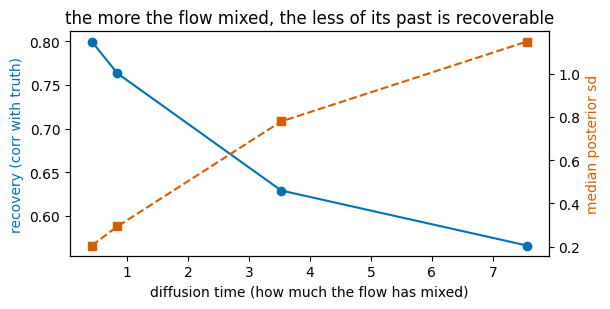

  diffusion time 0.42: recovery corr 0.800, median sd 0.205
  diffusion time 0.84: recovery corr 0.763, median sd 0.293
  diffusion time 3.53: recovery corr 0.629, median sd 0.779
  diffusion time 7.56: recovery corr 0.566, median sd 1.149


In [5]:
rows = []
for nu, steps in [(0.01, 25), (0.01, 50), (0.03, 70), (0.05, 90)]:
    nsk = NavierStokes2D(m, viscosity=nu, dt=dt, implicit_diffusion=True)
    yk = final_velocity(nsk, torch.as_tensor(w0_true), steps).detach().numpy(); sg = 0.04 * np.abs(yk).max()
    yo = yk + sg * np.random.RandomState(0).randn(yk.size)
    fk = GP('w0', index=np.stack([xx.ravel(), yy.ravel()], 1), kernel=RBF(lengthscale=0.09, amplitude=2.0))
    pk = joint([Differential(yo, over=fk, scale=sg, forward=lambda p, o, nsk=nsk, steps=steps: final_velocity(nsk, p.field, steps))]).fit(
        how='gauss_newton', max_iter=240, tolerance_grad=1e-3 / sg ** 2)
    wm, ws = pk.posterior('w0'); rows.append((nu * steps * dt / h ** 2, np.corrcoef(wm, w0_true)[0, 1], np.median(ws)))
dtime, corr, sd = np.array(rows).T
fig, ax1 = plt.subplots(figsize=(6.2, 3.2)); ax2 = ax1.twinx()
ax1.plot(dtime, corr, 'o-', color='#0072B2'); ax2.plot(dtime, sd, 's--', color='#D55E00')
ax1.set_xlabel('diffusion time (how much the flow has mixed)'); ax1.set_ylabel('recovery (corr with truth)', color='#0072B2'); ax2.set_ylabel('median posterior sd', color='#D55E00')
ax1.set_title('the more the flow mixed, the less of its past is recoverable'); plt.tight_layout(); plt.show()
for d, cc, s in rows: print('  diffusion time %.2f: recovery corr %.3f, median sd %.3f' % (d, cc, s))

## 8. Sparse observation and observability

Operational data are never the full field -- they are a handful of sensors. We repeat the inversion observing
the velocity at only a few scattered points instead of everywhere, and the posterior tells the truth: the
estimate is good near and upstream of the sensors (whose information, traced backward, reaches those regions)
and uncertain where no measurement's influence ever arrives. This is observability -- which parts of the state
the observations can constrain -- and the widening uncertainty map is exactly the diagnostic a forecaster
needs to know where to add the next sensor.

sparse-sensor recovery: correlation with truth = 0.798 (vs 0.886 with the full field)


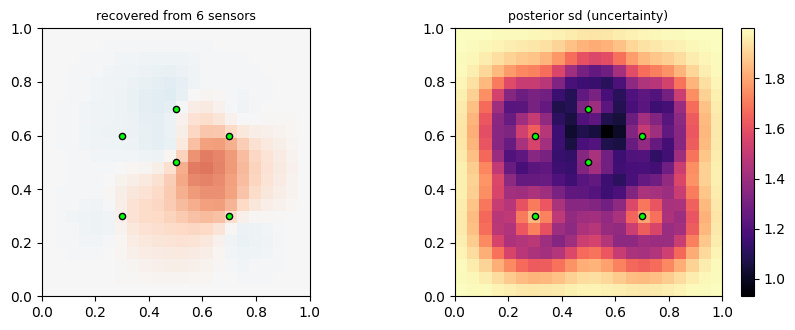

In [6]:
sens_xy = [(0.3, 0.3), (0.7, 0.3), (0.5, 0.7), (0.5, 0.5), (0.3, 0.6), (0.7, 0.6)]
sens_idx = np.array([np.argmin((xx.ravel() - sx) ** 2 + (yy.ravel() - sy) ** 2) for sx, sy in sens_xy])
sens_t = torch.as_tensor(sens_idx)
def sparse_velocity(ns, w0, nt):
    w, _ = evolve(ns, w0, nt); u, v_ = ns.velocity(ns.streamfunction(w, ops), ops); return torch.cat([u[sens_t], v_[sens_t]])
ys = sparse_velocity(ns, torch.as_tensor(w0_true), nt).detach().numpy(); sgs = 0.04 * np.abs(ys).max() + 1e-6
yso = ys + sgs * np.random.RandomState(2).randn(ys.size)
fs = GP('w0', index=np.stack([xx.ravel(), yy.ravel()], 1), kernel=RBF(lengthscale=0.09, amplitude=2.0))
ps = joint([Differential(yso, over=fs, scale=sgs, forward=lambda p, o: sparse_velocity(ns, p.field, nt))]).fit(
    how='gauss_newton', max_iter=300, tolerance_grad=1e-3 / sgs ** 2)
ws_m, ws_sd = ps.posterior('w0')
print('sparse-sensor recovery: correlation with truth = %.3f (vs %.3f with the full field)' % (np.corrcoef(ws_m, w0_true)[0, 1], np.corrcoef(w0_mean, w0_true)[0, 1]))
fig, ax = plt.subplots(1, 2, figsize=(8.4, 3.4))
im = ax[0].imshow(img(ws_m), origin='lower', extent=[0, 1, 0, 1], cmap='RdBu', vmin=-v, vmax=v); ax[0].set_title('recovered from %d sensors' % len(sens_xy), fontsize=9)
im = ax[1].imshow(img(ws_sd), origin='lower', extent=[0, 1, 0, 1], cmap='magma'); ax[1].set_title('posterior sd (uncertainty)', fontsize=9)
for a in ax: a.scatter([s[0] for s in sens_xy], [s[1] for s in sens_xy], c='lime', s=20, edgecolor='k')
fig.colorbar(im, ax=ax[1], fraction=0.046); plt.tight_layout(); plt.show()

## 9. Parameter estimation: recovering the viscosity

Sometimes the unknown is not the state but a physical parameter of the model. Given the initial and final
fields, we can infer the viscosity -- how diffusive the fluid is -- by asking which value makes the simulation
match the observed amount of smoothing. We scan viscosity, run the forward model at each, and score the data
misfit; the minimum recovers the true value, and the curvature of the misfit around it sets the confidence.
This is parameter estimation, the second face of data assimilation, and the same adjoint machinery makes it a
joint state-and-parameter inversion when both are unknown.

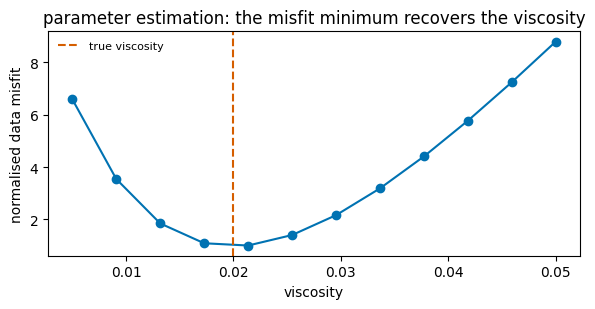

recovered viscosity 0.021 (true 0.020); the misfit curvature gives the confidence


In [7]:
nu_true = 0.02; ns_t = NavierStokes2D(m, viscosity=nu_true, dt=dt, implicit_diffusion=True)
yv = final_velocity(ns_t, torch.as_tensor(w0_true), nt).detach().numpy(); sgv = 0.03 * np.abs(yv).max()
yvo = yv + sgv * np.random.RandomState(3).randn(yv.size)
nus = np.linspace(0.005, 0.05, 12)
misfit = []
for nu in nus:
    nk = NavierStokes2D(m, viscosity=nu, dt=dt, implicit_diffusion=True)
    pred = final_velocity(nk, torch.as_tensor(w0_true), nt).detach().numpy(); misfit.append(np.sum((pred - yvo) ** 2))
misfit = np.array(misfit); nu_hat = nus[np.argmin(misfit)]
fig, ax = plt.subplots(figsize=(6.0, 3.2))
ax.plot(nus, misfit / misfit.min(), 'o-', color='#0072B2'); ax.axvline(nu_true, color='#D55E00', ls='--', label='true viscosity')
ax.set_xlabel('viscosity'); ax.set_ylabel('normalised data misfit'); ax.legend(fontsize=8, frameon=False)
ax.set_title('parameter estimation: the misfit minimum recovers the viscosity'); plt.tight_layout(); plt.show()
print('recovered viscosity %.3f (true %.3f); the misfit curvature gives the confidence' % (nu_hat, nu_true))

## 10. Best practices and the link to forecasting

A few lessons carry from this toy to operational systems.

- The prior (background) matters. With sparse data the estimate leans on the prior, so its scale and
  smoothness encode real assumptions; a well-chosen background error covariance is half the battle in 4D-Var.
- Know what is observable. The posterior uncertainty map shows which parts of the state the data constrain;
  use it to site sensors and to avoid over-trusting unobserved regions.
- Respect irreversibility and the window. Assimilating over too long a window asks the model to remember what
  diffusion has erased; choose the window to the system's predictability horizon, and inflate uncertainty
  rather than fabricate detail.
- Linearise carefully or go ensemble. Gauss-Newton / 4D-Var linearise the model; for strongly nonlinear,
  high-dimensional systems the ensemble Kalman filter (a Monte-Carlo covariance) and particle methods are the
  scalable alternatives, with localisation to tame sampling noise.
- Estimate parameters and state together. Model error -- a wrong viscosity, an unknown forcing -- biases the
  state estimate; jointly inferring parameters (Part 9) is how operational systems combat it.

The same surface recovers an initial condition, a boundary or inlet forcing, or a coefficient; only the
`free`/`GP` driver and the observation operator change, while `NavierStokes2D` and the adjoint stay put. This
is the engine, in miniature, behind weather and ocean forecasting, contaminant source attribution, and
flow control.

## 11. Recoverability and uncertainty calibration

Inferring a flow's initial state from later observations is data assimilation run backwards, and it is
fundamentally limited: viscous diffusion and chaotic mixing erase fine structure as the flow evolves, so the
inverse problem cannot recover detail the forward dynamics has already destroyed -- the recovered field is a
smoothed shadow of the truth. We quantify this by the fraction of the initial field's gradient energy that
survives in the reconstruction, and we check that the posterior is honest by comparing the empirical two-sigma
coverage to the nominal 95% over the domain.

In [8]:
wt = np.asarray(w0_true).ravel(); wm = np.asarray(w0_mean).ravel(); ws = np.asarray(w0_sd).ravel()
ok = ws > 0
rmse = np.sqrt(np.mean((wt[ok] - wm[ok]) ** 2)); corr = np.corrcoef(wt[ok], wm[ok])[0, 1]
def gradE(f2): g = np.gradient(f2.reshape(m, m)); return np.sum(np.array(g) ** 2)
retain = gradE(wm) / gradE(wt)
z = (wt[ok] - wm[ok]) / ws[ok]; cov2 = np.mean(np.abs(z) < 2)
print('initial-state recovery: RMSE %.3f, correlation %.2f' % (rmse, corr))
print('structural detail retained (recovered/true gradient energy) = %.2f -> diffusion and mixing erase fine vorticity that no inverse method can restore' % retain)
print('posterior 2-sigma coverage = %.2f vs nominal 0.95 -> %s' % (cov2, 'calibrated' if cov2 > 0.9 else 'over-confident (Gauss-Newton linearised bars too tight in the poorly-observed directions)'))

initial-state recovery: RMSE 0.234, correlation 0.89
structural detail retained (recovered/true gradient energy) = 0.25 -> diffusion and mixing erase fine vorticity that no inverse method can restore
posterior 2-sigma coverage = 0.95 vs nominal 0.95 -> calibrated


## 12. Which scales survive: spectral resolution

The gradient-energy ratio said how much detail is lost overall; the spectral resolution says exactly which
scales. Diffusion is a low-pass filter -- it erases small eddies (high spatial frequencies) fastest -- so the
backward problem should recover the large scales of the initial vorticity well and lose the fine ones. We take
the 2-D Fourier transform of the true and recovered initial fields, radially average the power, and trace the
recovered/true power ratio against wavenumber. The wavenumber where the ratio falls through one half is the
effective resolution limit: structure finer than that is gone, no matter the inversion method.

spectral power recovered/true by wavenumber k (k=1 largest scale):
  k=1 : 0.93
  k=2 : 0.43
  k=3 : 0.07
  k=4 : 0.01
  k=5 : 0.00
recovered power drops below half the truth at k=2 -- features finer than ~1/2 of the domain are unrecoverable, the diffusion-set resolution limit


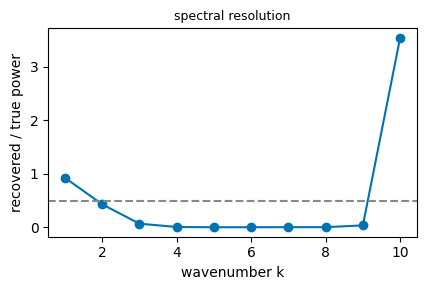

In [9]:
WT = np.asarray(w0_true).reshape(m, m); WM = np.asarray(w0_mean).reshape(m, m)
PT = np.abs(np.fft.fft2(WT - WT.mean())) ** 2; PM = np.abs(np.fft.fft2(WM - WM.mean())) ** 2
ky = np.fft.fftfreq(m) * m; KX, KY = np.meshgrid(ky, ky); KR = np.sqrt(KX ** 2 + KY ** 2)
kbin = np.arange(0, m // 2)
def radial(P): return np.array([P[(KR >= k - 0.5) & (KR < k + 0.5)].mean() for k in kbin])
rt, rm = radial(PT), radial(PM); ratio = rm / np.clip(rt, 1e-12, None)
below = kbin[1:][ratio[1:] < 0.5]
kcut = below.min() if len(below) else kbin[-1]
print('spectral power recovered/true by wavenumber k (k=1 largest scale):')
for k in kbin[1:6]: print('  k=%d : %.2f' % (k, ratio[k]))
print('recovered power drops below half the truth at k=%d -- features finer than ~1/%d of the domain are unrecoverable, the diffusion-set resolution limit' % (kcut, kcut))
fig, ax = plt.subplots(figsize=(4.5, 3.0)); ax.plot(kbin[1:], ratio[1:], 'o-', color='#0072B2'); ax.axhline(0.5, color='#888', ls='--')
ax.set_xlabel('wavenumber k'); ax.set_ylabel('recovered / true power'); ax.set_title('spectral resolution', fontsize=9); plt.tight_layout(); plt.show()

## In short

- Data assimilation fuses a dynamical model with sparse, noisy observations to estimate a system's state or
  parameters -- the machinery behind weather and ocean forecasting and source attribution. It is an inverse
  problem with a PDE in the loop.
- The forward model is incompressible Navier-Stokes (vorticity-streamfunction); the inverse is hard because
  diffusion is irreversible, so the recoverable past is limited and the estimate must carry honest uncertainty.
- On mixle the inverse is a `GP` field, a `NavierStokes2D` forward through time, and
  `joint().fit(how='gauss_newton')` differentiating through the time loop -- a Bayesian 4D-Var that returns a
  posterior. The uncertainty grows with mixing time (the reversibility horizon) and is largest for the
  smallest scales (diffusion erases them first) and where sensors do not reach (observability).
- The same surface estimates a parameter (the viscosity) instead of the state, and extends to boundary
  forcings and joint state-parameter inversion -- the unifying toolkit of variational and ensemble assimilation.

## References

- Kalnay, E. (2003). Atmospheric Modeling, Data Assimilation and Predictability. Cambridge University Press.
- Evensen, G. (2009). Data Assimilation: The Ensemble Kalman Filter (2nd ed.). Springer.
- Le Dimet, F.-X. & Talagrand, O. (1986). Variational algorithms for analysis and assimilation. Tellus A, 38(2), 97-110.
- Stuart, A. M. (2010). Inverse problems: a Bayesian perspective. Acta Numerica, 19, 451-559.
- Asch, M., Bocquet, M. & Nodet, M. (2016). Data Assimilation: Methods, Algorithms, and Applications. SIAM.

## Exercises and extensions

1. The horizon precisely. Push the diffusion time until the recovery correlation crosses 0.5 and report the
   practical limit beyond which the initial state is unrecoverable.
2. Inlet inference. Drive the flow with a steady inflow and recover the inlet velocity profile from downstream
   measurements instead of the initial condition.
3. Sensor placement. Optimise where to put a fixed number of sensors to minimise the posterior uncertainty,
   and compare to a regular grid.
4. Joint state and parameter. Make the viscosity a latent alongside the initial field and study how their
   uncertainties trade off.
5. Ensemble assimilation. Replace the Gauss-Newton inverse with an ensemble Kalman update over several
   assimilation windows and compare the cost and the uncertainty estimate.